### Setup imports and plotting configuration


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8_whitegrid' if 'seaborn-v0_8_whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100


## 1. Linear Spacing ('np.linspace)
### overview and purpose

**Overview**

`np.linspace` is a NumPy function that returns evenly spaced numbers over a specified interval. Unlike `np.arange` which uses a step size, `linspace` takes a start point, end point, and the *number of samples* to generate, making it ideal when you know how many points you need rather than the step between them.

**Purpose**

- Generate sequences for plotting, sampling, or discretizing continuous domains
- Create coordinate grids for function evaluation (e.g., `x = np.linspace(0, 2*np.pi, 100)`)
- Ensure the endpoint is included by default (`endpoint=True`), which is often desired for plotting boundaries
- Avoid floating-point accumulation errors that can occur with repeated addition in `arange`
- Provide a convenient way to partition an interval into `N` equal subintervals (yielding `N+1` points if endpoint included)

## 1. Linear Spacing ('np.linspace)
### overview and purpose

**Overview**

`np.linspace` is a NumPy function that returns evenly spaced numbers over a specified interval. Unlike `np.arange` which uses a step size, `linspace` takes a start point, end point, and the *number of samples* to generate, making it ideal when you know how many points you need rather than the step between them.

**Purpose**

- Generate sequences for plotting, sampling, or discretizing continuous domains
- Create coordinate grids for function evaluation (e.g., `x = np.linspace(0, 2*np.pi, 100)`)
- Ensure the endpoint is included by default (`endpoint=True`), which is often desired for plotting boundaries
- Avoid floating-point accumulation errors that can occur with repeated addition in `arange`
- Provide a convenient way to partition an interval into `N` equal subintervals (yielding `N+1` points if endpoint included)

$\displaystyle x_i = \text{start} + i \cdot \frac{\text{stop} - \text{start}}{N - 1},\quad i = 0, 1, \dots, N-1$ (with `endpoint=True`)


[ 0.          0.71428571  1.42857143  2.14285714  2.85714286  3.57142857
  4.28571429  5.          5.71428571  6.42857143  7.14285714  7.85714286
  8.57142857  9.28571429 10.        ]
0.7142857142857143
[ 0.          0.71428571  1.42857143  2.14285714  2.85714286  3.57142857
  4.28571429  5.          5.71428571  6.42857143  7.14285714  7.85714286
  8.57142857  9.28571429 10.        ]


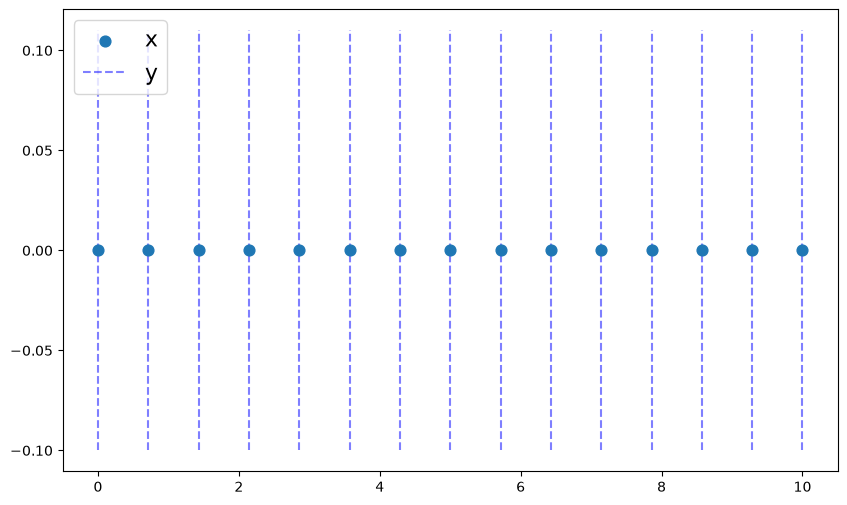

In [21]:
x_linear, step_size = np.linspace(start=0.0, stop=10.0, num=15, retstep=True)
print(x_linear)
print(step_size)
print(np.linspace(0.0, 10.0, 15, endpoint=True))
plt.figure(figsize=(10, 6))
plt.scatter(x_linear,np.zeros_like(x_linear), s=60,zorder = 3)
plt.vlines(x_linear, ymin=-0.1, ymax=0.11 ,color = "blue", linestyles='--',alpha = 0.5)
plt.legend(("x", "y"), loc="upper left", fontsize=16)

plt.show()


Logaritmic space array: [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01]
Generated array:
Learning rates: ['0.000010', '0.000100', '0.001000', '0.010000', '0.100000', '1.000000', '10.000000']


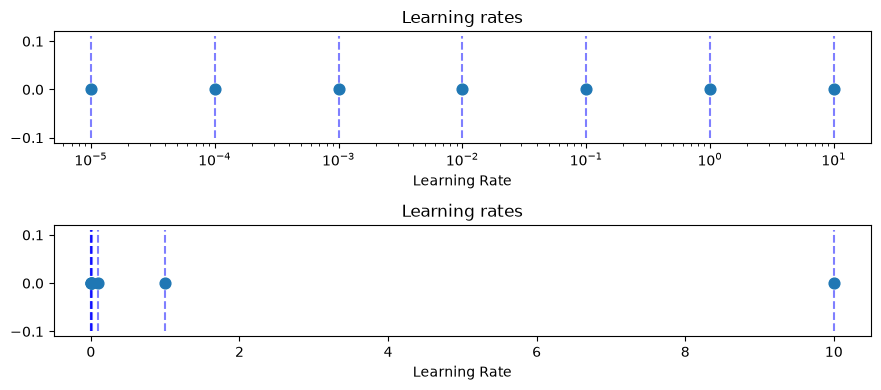

In [27]:
# generate 7 points from 10^-5 to 10^1 using logarithmic spacing
# print(x_log)
# print(np.logspace(1, 5, 7, endpoint=True))
# plt.figure(figsize=(10, 6))
# plt.scatter(x_log,np.zeros_like(x_log), s=60,zorder = 3)
# plt.vlines(x_log, ymin=-0.1, ymax=0.11 ,color = "blue", linestyles='--',alpha = 0.5)
# plt.legend(("x", "y"), loc="upper left", fontsize=16)
# plt.show()

learning_rate = np.logspace(start=-5, stop=1, num=7,base=10)
print("Logaritmic space array:",learning_rate)
print("Generated array:")
print("Learning rates:",[f"{lr:.6f}" for lr in learning_rate])

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(9,4))

ax1.scatter(learning_rate, np.zeros_like(learning_rate), s=60, zorder=3)
ax1.vlines(learning_rate, ymin=-0.1, ymax=0.11, color="blue", linestyles='--', alpha=0.5)
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('')
ax1.set_xscale('log')
ax1.set_title('Learning rates')

ax2.scatter(learning_rate, np.zeros_like(learning_rate), s=60, zorder=3)
ax2.vlines(learning_rate, ymin=-0.1, ymax=0.11, color="blue", linestyles='--', alpha=0.5)
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('')
ax2.set_title('Learning rates')

plt.tight_layout()
plt.show()



## 3. Geometric Spacing (np.geomspace)
`np.geomspace` is used to generate a sequence of numbers that are spaced evenly on a log scale, creating a geometric progression. It is similar to `np.logspace`, but it allows you to specify the start and end values directly instead of their exponents.

### Purpose:
- **Logarithmic Sampling:** Ideal for generating values that span multiple orders of magnitude, such as frequencies or learning rates.
- **Geometric Progressions:** Useful when each term in a sequence needs to be a constant multiple of the previous one.
- **Ease of Use:** Provides a more intuitive way to define logarithmic ranges when the exact start and end points are known.

### Mathematical formula

$ x_i = x_{\text{start}} \left( \frac{x_{\text{end}}}{x_{\text{start}}} \right)^{\frac{i}{N-1}}, \quad i = 0, 1, 2, \dots, N-1 $

This means each value is a constant ratio times the previous one, so the sequence grows geometrically between the start and end values.


Geometric Space Array: [   1.            3.98107171   15.84893192   63.09573445  251.18864315
 1000.        ]
Common Multiplicative ratio of geometric space array: 3.9811


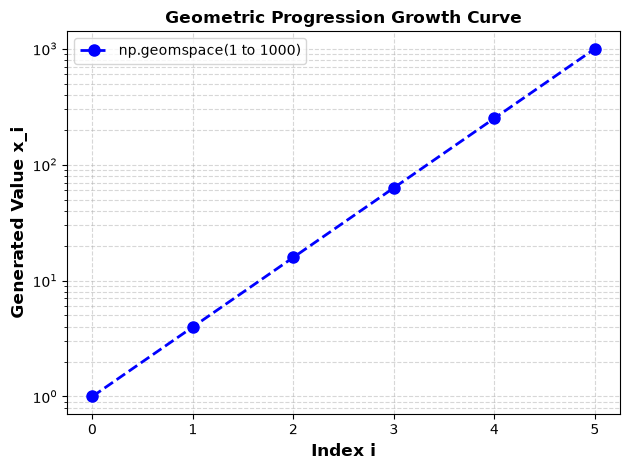

In [34]:
geom_grid = np.geomspace(start=1.0, stop=1000.0, num=6)
print("Geometric Space Array:", geom_grid)
print(f"Common Multiplicative ratio of geometric space array: {geom_grid[1]/geom_grid[0]:.4f}")

plt.plot(range(len(geom_grid)), geom_grid, 'o--', color = 'blue',linewidth = 2, markersize = 8, label = 'np.geomspace(1 to 1000)')

plt.title('Geometric Progression Growth Curve', fontsize = 12, fontweight = 'bold')
plt.xlabel('Index i', fontsize = 12, fontweight = 'bold')
plt.ylabel('Generated Value x_i', fontsize = 12, fontweight = 'bold')
plt.yscale('log')
plt.grid(True,which='both', ls='--',alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()


In [39]:
x_domain = np.linspace(0, 1, 1000)
y_domain = np.linspace(0, 1, 1000)
X,Y = np.meshgrid(x_domain, y_domain)
Z = X**2 + Y**2
print("Grid Coordinate output:")
print(f"X matrix {X.shape}")
print(f"Y matrix {Y.shape}")
print(f"Z matrix {Z.shape}")
print("\nSample X matrix slice (first 3 x 3 block):\n\n",X[:3,:3])
print("\nSample Y matrix slice (first 3 x 3 block):\n\n",Y[:3,:3])
print("\nSample Z matrix slice (first 3 x 3 block):\n\n",Z[:3,:3])
print()


Grid Coordinate output:
X matrix (1000, 1000)
Y matrix (1000, 1000)
Z matrix (1000, 1000)

Sample X matrix slice (first 3 x 3 block):

 [[0.       0.001001 0.002002]
 [0.       0.001001 0.002002]
 [0.       0.001001 0.002002]]

Sample Y matrix slice (first 3 x 3 block):

 [[0.       0.       0.      ]
 [0.001001 0.001001 0.001001]
 [0.002002 0.002002 0.002002]]

Sample Z matrix slice (first 3 x 3 block):

 [[0.00000000e+00 1.00200300e-06 4.00801202e-06]
 [1.00200300e-06 2.00400601e-06 5.01001502e-06]
 [4.00801202e-06 5.01001502e-06 8.01602403e-06]]

